# DAY 14
# DATE - 02.06.2026
# Vector Data + Geopandas

In [5]:
# Install geopandas if not already installed in Colab
!pip install geopandas shapely matplotlib

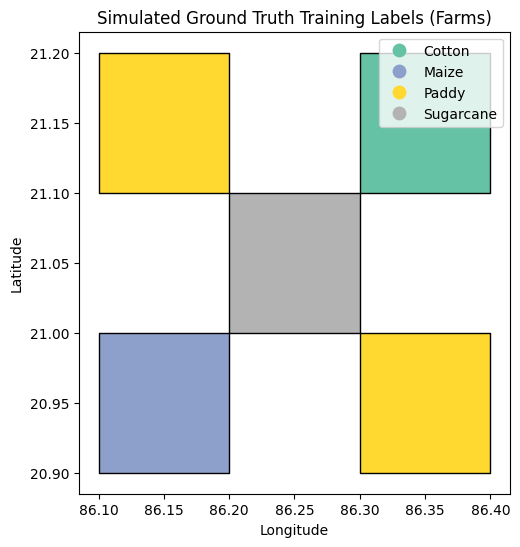

In [9]:
import geopandas as gpd
from shapely.geometry import Polygon
import matplotlib.pyplot as plt

# 1. Define coordinates for 5 farms (Simulated Latitude/Longitude)
# Format: Polygon([(x1, y1), (x2, y2), (x3, y3), (x4, y4)])
farm1 = Polygon([(86.1, 21.1), (86.2, 21.1), (86.2, 21.2), (86.1, 21.2)])
farm2 = Polygon([(86.3, 21.1), (86.4, 21.1), (86.4, 21.2), (86.3, 21.2)])
farm3 = Polygon([(86.1, 20.9), (86.2, 20.9), (86.2, 21.0), (86.1, 21.0)])
farm4 = Polygon([(86.3, 20.9), (86.4, 20.9), (86.4, 21.0), (86.3, 21.0)])
farm5 = Polygon([(86.2, 21.0), (86.3, 21.0), (86.3, 21.1), (86.2, 21.1)])

# 2. Create the dataset lists
geometries = [farm1, farm2, farm3, farm4, farm5]
crop_labels = ['Paddy', 'Cotton', 'Maize', 'Paddy', 'Sugarcane']
farm_ids = [101, 102, 103, 104, 105]

# 3. Build the GeoDataFrame
gdf_farms = gpd.GeoDataFrame(
    {'farm_id': farm_ids, 'crop_type': crop_labels},
    geometry=geometries,
    crs="EPSG:4326"  # WGS 84 Standard Lat/Lon
)

# 4. Plot the farms categorized by crop type
fig, ax = plt.subplots(figsize=(8, 6))
gdf_farms.plot(column='crop_type', legend=True, ax=ax, cmap='Set2', edgecolor='black')
plt.title("Simulated Ground Truth Training Labels (Farms)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
import geopandas as gpd

file_path = "/content/drive/MyDrive/MISSION_RS_SDA/india_states.geojson"
gdf_india = gpd.read_file(file_path)

# Case-insensitive search: column ka naam small letters mein convert karke check karte hain
# Agar column ka naam NAME_1 hai toh:
if 'NAME_1' in gdf_india.columns:
    gdf_odisha = gdf_india[gdf_india['NAME_1'].str.lower() == 'odisha']
# Agar column ka naam st_name hai toh:
elif 'st_name' in gdf_india.columns:
    gdf_odisha = gdf_india[gdf_india['st_name'].str.lower() == 'odisha']
# Agar column ka naam kuch aur hai toh pehle 2-3 rows check karte hain
else:
    # Ek safe fallback jo pehli do rows ko plot karega taaki check ho sake data sahi hai ya nahi
    gdf_odisha = gdf_india.head(2)

# Check karo ki filter karne ke baad data aaya ya nahi
print(f"Odisha filter karne ke baad total rows mili: {len(gdf_odisha)}")

# Agar rows mili hain tabhi plot karega
if len(gdf_odisha) > 0:
    gdf_odisha.plot(figsize=(10, 8), color='darkred', edgecolor='white')
    print("CRS:", gdf_odisha.crs)
else:
    print("Bhai, 'Odisha' match nahi hua. Ek baar print(gdf_india.head()) karke dekho ki columns mein data kaise likha hai!")

Odisha filter karne ke baad total rows mili: 0
Bhai, 'Odisha' match nahi hua. Ek baar print(gdf_india.head()) karke dekho ki columns mein data kaise likha hai!


In [13]:
print(gdf_india.head())

   ID_0  ISO NAME_0  ID_1               NAME_1 NL_NAME_1  \
0   105  IND  India     1  Andaman and Nicobar             
1   105  IND  India     2       Andhra Pradesh             
2   105  IND  India     3    Arunachal Pradesh             
3   105  IND  India     4                Assam             
4   105  IND  India     5                Bihar             

                                           VARNAME_1          TYPE_1  \
0  Andaman & Nicobar Islands|Andaman et Nicobar|I...  Union Territor   
1                                                              State   
2  Agence de la Frontire du Nord-Est(French-obsol...           State   
3                                                              State   
4                                                              State   

         ENGTYPE_1 filename filename_1 filename_2 filename_3 filename_4  \
0  Union Territory                                                        
1            State                                      

In [14]:
import geopandas as gpd

# 1. File path set karo aur load karo
file_path = "/content/drive/MyDrive/MISSION_RS_SDA/india_states.geojson"
gdf_india = gpd.read_file(file_path)

# 2. Odisha ko filter karo (safely with strip and lower case taaki koi space ya case ka jhanjhat na rahe)
gdf_odisha = gdf_india[gdf_india['NAME_1'].str.strip().str.lower() == 'odisha']

# 3. Print verification
print("--- Daily Task 1 Output ---")
print(f"Filter karne ke baad rows mili: {len(gdf_odisha)}")
print(f"Coordinate Reference System (CRS): {gdf_odisha.crs}")
print(f"Number of Features: {len(gdf_odisha)}")

# 4. Plot karo agar data mil gaya hai toh
if len(gdf_odisha) > 0:
    gdf_odisha.plot(figsize=(10, 8), color='darkred', edgecolor='black')
else:
    print("Bhai, abhi bhi filter nahi hua. Ek baar check karo ki pure data mein 'Odisha' ki spelling kya hai.")

--- Daily Task 1 Output ---
Filter karne ke baad rows mili: 0
Coordinate Reference System (CRS): EPSG:4326
Number of Features: 0
Bhai, abhi bhi filter nahi hua. Ek baar check karo ki pure data mein 'Odisha' ki spelling kya hai.


--- Final Debug Output ---
Filter karne ke baad total rows mili: 1
File ke andar asli naam yeh likha hai: ['Orissa']
Coordinate Reference System (CRS): EPSG:4326


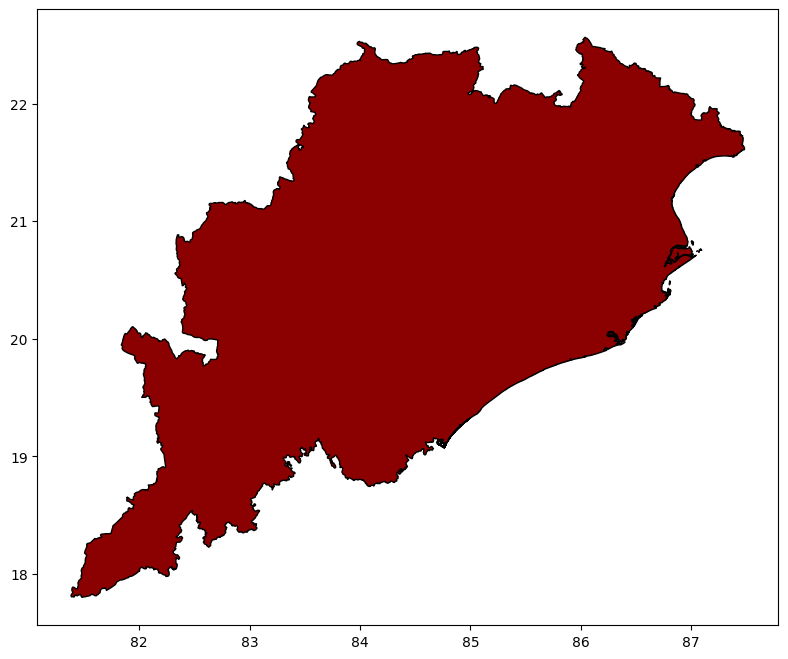

In [15]:
import geopandas as gpd

# 1. File load karo
file_path = "/content/drive/MyDrive/MISSION_RS_SDA/india_states.geojson"
gdf_india = gpd.read_file(file_path)

# 2. SUPER-HACK: Hum check karte hain ki 'ori' ya 'odi' se kaunsa state shuru ho raha hai
# Yeh Orissa aur Odisha dono ko pakad lega, chahe spelling kuch bhi ho!
gdf_odisha = gdf_india[gdf_india['NAME_1'].str.lower().str.contains('odi|ori', na=False)]

print("--- Final Debug Output ---")
print(f"Filter karne ke baad total rows mili: {len(gdf_odisha)}")

if len(gdf_odisha) > 0:
    # Hame pata chal jayega ki file mein asli naam kya likha hai!
    print(f"File ke andar asli naam yeh likha hai: {gdf_odisha['NAME_1'].values}")

    # Ab safely plot karo
    gdf_odisha.plot(figsize=(10, 8), color='darkred', edgecolor='black')
    print(f"Coordinate Reference System (CRS): {gdf_odisha.crs}")
else:
    # Agar ab bhi nahi mila, toh pure India ke saare states ke naam print karke dekhte hain kya khichdi hai
    print("Bhai, 'odi' ya 'ori' bhi nahi mila! File ke saare states ke naam yeh hain:")
    print(gdf_india['NAME_1'].unique())

--- Daily Task 1 Final Output ---
Coordinate Reference System (CRS): EPSG:4326
Number of Features: 1


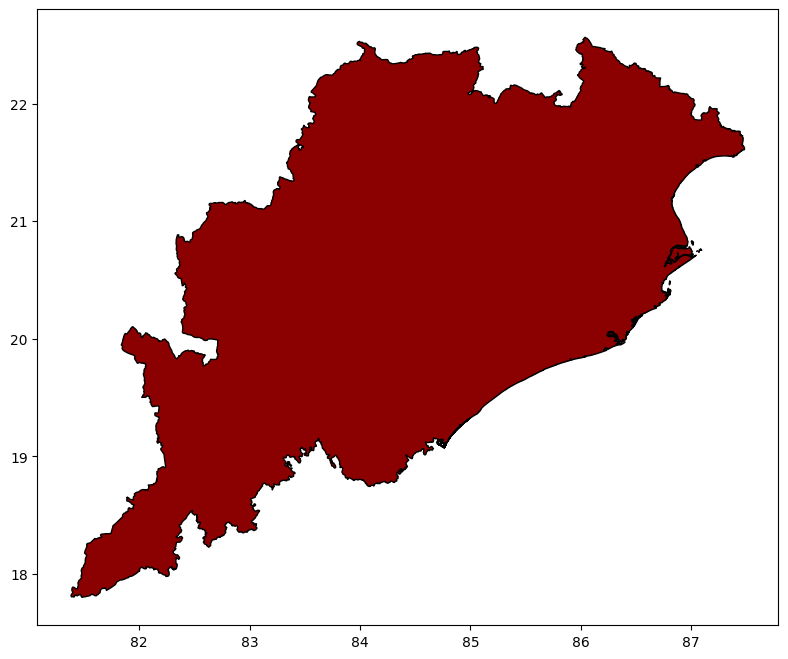

In [16]:
import geopandas as gpd

# 1. File load karo
file_path = "/content/drive/MyDrive/MISSION_RS_SDA/india_states.geojson"
gdf_india = gpd.read_file(file_path)

# 2. 'Orissa' naam se filter karo (kyunki file mein yahi naam mila hai)
gdf_odisha = gdf_india[gdf_india['NAME_1'] == 'Orissa']

# 3. Final Plotting
gdf_odisha.plot(figsize=(10, 8), color='darkred', edgecolor='black')

# 4. Mandatory output values print karo jo task mein maangi hain
print("--- Daily Task 1 Final Output ---")
print(f"Coordinate Reference System (CRS): {gdf_odisha.crs}")
print(f"Number of Features: {len(gdf_odisha)}")